
# Project Milestone One: Forming Your Team, Understanding the Problem & Exploring the Data



### **Due:** Midnight on October 26th (with 2-hour grace period) — **worth 25 points**

> **Note:** Because we must begin manual grading immediately, there will be *no* late period for this milestone.



This milestone is the first phase of your project. You’ll begin working in teams, select your dataset, perform basic exploratory data analysis (EDA), and frame your classification problem.  

1. **Form your project team.**  
   Convene your team and complete the **Team Contract** (available in your Homework Repository). This is **due on Sunday, October 19th** at midnight (along with Homework 07). Each member must review and sign it before submission.

2. **Select a team leader.**  
   Choose one team member to act as the **Gradescope submitter** for your team. The entire team should collaborate on the notebook, but only the leader will submit.

3. **Explore your dataset and frame your task.**  
   You’ll work through the notebook to  
   - Examine both provided datasets,  
   - Choose one for your project,
   - Be able to describe the classification problem you’ll be solving in business or applied terms,
   - Conduct basic EDA to understand its structure and challenges, and
   - Spot potential challenges, propose solutions, and select appropriate performance metrics.  

This milestone focuses on understanding your data and clearly articulating what your model will eventually predict. You are not required to build a model yet (that will happen in Milestone 2) but of course you have lots of example models to choose from previous Homeworks and Coding Notebooks and you may wish to explore a baseline model as you do this first phase of your project.




### **The Datasets**

The final project is a **classification task** using **one of two datasets**—one image-based and one text-based. These are the two
domains we have studied in detail, after learning the fundamentals in the first three weeks, and you have all you need to approach either of these datasets with confidence.



#### **1. Food-101 (Images)**  
  - A web-scraped collection of approximately **101,000 color photos** across **101 food categories** (≈ 800 train / 100 validation / 100 test per class).
  
  - Images vary widely in **lighting, composition, and color balance**, making this dataset excellent for practicing **data cleaning**, **EDA**, and **augmentation** techniques such as random crops, flips, and color jitter.

#### **2. HuffPost News Category (Text)**  
- Roughly **200,000 short news items** labeled into **41 topical categories** (e.g., *POLITICS*, *ENTERTAINMENT*, *PARENTING*).  
Each record contains a **headline**, a **short description**, which we will concatenate with a separator token to make a single text string:
> `"headline [SEP] short_description"`.
>
- The `[SEP]` token simply marks where the headline ends and the description begins—mirroring conventions used in transformer models such as BERT.




### **What To Do**




We’ve provided template code to start your project:

* **Download** your selected dataset.
* **Visualize** a few representative samples (images or text excerpts).

After reviewing both datasets, you’ll **choose one** for your semester project.

In the sections that follow:

* **Problem One — Exploratory Data Analysis (EDA):**
  Quantify scale and structure, check class balance, and note any missing/duplicate or inconsistent entries.

* **Problem Two — Challenges & Solution Paths:**
  Identify likely issues (e.g., overlapping categories, imbalanced labels, data-quality problems, length/size variance) and outline practical remedies you would try. *(No model training required.)*

For tips on working with **Hugging Face Datasets** (helpful for large datasets), see the **Appendix**.

> **Important:** Keep only the section for the dataset you select and delete the other before submitting **Milestone 1**.


## Imports

In [ ]:
# ============================================
# Useful Imports
# ============================================

# --- Standard Libraries
import os
import time
import math
import random
from collections import Counter
import re
import nltk
from nltk.corpus import stopwords

# --- Core Data / Numerics
import numpy as np
import pandas as pd

# --- Visualization
import matplotlib.pyplot as plt
import seaborn as sns              # optional
import matplotlib.ticker as mticker  # optional (for formatted axes)

# --- NLP / Tokenization
import spacy                         # used for text preprocessing (HuffPost)

# --- Progress Tracking
from tqdm import tqdm                # optional (nice for loops)

from IPython.display import display

# --- TensorFlow / Keras (Deep Learning)
import tensorflow as tf
from tensorflow.keras import layers, models, Input, callbacks, regularizers, initializers
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.optimizers.schedules import CosineDecay, ExponentialDecay
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.layers import (
    Dense, Dropout, Flatten, MaxPooling2D, Conv2D,
    SeparableConv2D, GlobalAveragePooling2D, GlobalMaxPooling2D, BatchNormalization
)

# --- (Optional) Classical ML Baseline Tools
# from sklearn.pipeline import Pipeline
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score


# ============================================
# Global Configuration & Small Utilities
# ============================================

# Reproducibility
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
tf.keras.utils.set_random_seed(random_seed)   # sets Python, NumPy, and TensorFlow seeds

# Utility: format seconds as HH:MM:SS

"""
Example usage to time your code:

start_time = time.time()
# ... your code here ...
print("Execution Time:", format_hms(time.time() - start_time))
"""

def format_hms(seconds: float) -> str:
    """Convert seconds to HH:MM:SS format."""
    return time.strftime("%H:%M:%S", time.gmtime(seconds))


In [ ]:

sns.set_theme(font_scale=0.9)
# plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.titlesize']  = 10
plt.rcParams['axes.labelsize']  = 8
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 4
plt.rcParams['axes.edgecolor']  = 'gray'
plt.rcParams['xtick.color']     = 'gray'
plt.rcParams['ytick.color'] = 'gray'
plt.rcParams['xtick.color'] = 'gray'
plt.rcParams['ytick.color'] = 'gray'
plt.rcParams['ytick.labelsize'] = 8
plt.rcParams['xtick.labelsize'] = 8

In [ ]:
# If needed (in a new env):
# !pip install -U datasets pillow

In [ ]:
# --- Hugging Face Datasets
from datasets import load_dataset, DatasetDict, load_from_disk
from datasets.features import ClassLabel

In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Functions

In [ ]:
# --- Function to preprocess text and get word frequencies ---
# def get_word_frequencies(text_series):
#     """
#     Cleans text by removing punctuation and stopwords, then counts word frequencies.
#     """
#     all_text  = ' '.join(text_series.fillna('')).lower()

#     # Remove special characters and punctuation, leaving only alphanumeric characters and spaces
#     all_text  = re.sub(r'[^a-z0-9\s]', '', all_text)
#     words     = all_text.split()

#     # Filter out stopwords and very short words (e.g., single letters)
#     filtered_words = [word for word in words if word not in stop_words and len(word) > 1]
#     return Counter(filtered_words)

## Prelude: Choose your dataset and take a first look

You’ll pick **one** dataset—either **Food-101 (images)** or **HuffPost (text)**—and run the starter cells to confirm it loads, view class stats, and skim a few samples.

* **Food-101 (images):** 101 classes of web photos with **inconsistent lighting, white balance, color casts, and composition** (plus varying resolutions). These natural quirks make augmentation and input-pipeline choices meaningful.
* **HuffPost (text):** ~200k headline/summary pairs across 41 topics with **class imbalance** and some **category overlap**—good for trying stratified splits and reporting macro-F1 in addition to accuracy.

After you review the two sections below (download → minimal EDA → split), **keep one and delete the other.** Stick with your choice for the entire project.

> **Note:** We use Hugging Face **Dataset/DatasetDict** objects (table-like datasets), not NumPy/Pandas arrays. Most of what you need to know is contained in the template code, but see the **Appendix** for more information on HG Datasets.


---

### Dataset One (Images): Food-101

#### **Load Food-101 as a Dataset**

> Note: this loads a **Hugging Face `Dataset`**, not NumPy or TensorFlow tensors.
> Each sample is stored as a **dictionary** with two keys — `"image"` (a PIL image object) and `"label"` (an integer class ID).
> You can access columns by name, e.g. `food_all["image"]` or `food_all["label"]`, and check the dataset size with `len(food_all)`.
> Unlike arrays, image sizes and aspect ratios may differ across samples — you’ll handle resizing or normalization later during preprocessing.


https://huggingface.co/prithivMLmods/Food-101-93M

<font color = 'plum'>Food-101-93M is a fine-tuned image classification model built on top of google/siglip2-base-patch16-224 using the SiglipForImageClassification architecture. It is trained to classify food images into one of 101 popular dishes, derived from the Food-101 dataset.


<font color = 'plum'>
The Food-101-93M model is intended for:

- Recipe Recommendation Engines: Automatically tagging food images to suggest recipes.
- Food Logging & Calorie Tracking Apps: Categorizing meals based on photos.
- Smart Kitchens: Assisting food recognition in smart appliances.
- Restaurant Menu Digitization: Auto-classifying dishes for visual menus or ordering systems.
- Dataset Labeling: Enabling automatic annotation of food datasets for training other ML models.

In [ ]:
# food_all = load_dataset("food101", split="train+validation")  # ~101k images total

# food_all.save_to_disk('/content/drive/My Drive/DX703/food_101_data')

In [ ]:
# food_all_data = load_from_disk('/content/drive/My Drive/DX703/food_101_data')

# label_col = "label"

# # Sanity check the label column
# assert label_col in food_all_data.features
# assert isinstance(food_all_data.features[label_col], ClassLabel)

# food_label_names = food_all_data.features[label_col].names
# print(f"Total images: {len(food_all_data):,}  |  Classes: {len(food_label_names)}")

#### **Quick sanity checks (rows, label ids, a few image sizes)**

In [ ]:
# # First 5 rows: label id → name
# for i in range(5):
#     y = food_all_data[i][label_col]
#     print(f"row {i}: id={y}, name={food_label_names[y]}")

# labels_list = list(food_all_data[label_col])
# print("labels length:", len(labels_list), "unique classes:", len(set(labels_list)))
# print("min/max label IDs:", min(labels_list), max(labels_list))

# for i in range(3):
#     print(f"image {i} size:", food_all_data[i]["image"].size)  # (W, H)

#### **Visual preview: random 3×3 grid from TRAIN**

In [ ]:
# n, cols, seed = 9, 3, 42
# idxs = random.Random(seed).sample(range(len(food_all_data)), n)
# rows = math.ceil(n/cols)

# plt.figure(figsize=(3*cols, 3*rows))
# for i, idx in enumerate(idxs, 1):
#     ex = food_all_data[idx]
#     plt.subplot(rows, cols, i)
#     plt.imshow(ex["image"]); plt.axis("off")
#     plt.title(food_label_names[ex[label_col]], fontsize=9)
# plt.tight_layout(); plt.show()

---

### Dataset Two (Text): HuffPost Dataset

#### **Load HuffPost (headline + summary + category)**

**Note:** This loads a **Hugging Face `Dataset`**, not a NumPy array or Pandas DataFrame.
- Each record is a **dictionary** with fields such as `"headline"`, `"short_description"`, and `"category"`.
- You can access columns by name (e.g., `huff["headline"]`) and check dataset size with `len(huff)`.
- Treat it as a table of text fields — you’ll handle tokenization and vectorization later during preprocessing.
- The typical BERT-compatible separator is used to construct the sample texts

        `headline [SEP] short-description`



https://huggingface.co/datasets/khalidalt/HuffPost

A dataset of approximately 200K news headlines from the year 2012 to 2018 collected from HuffPost.

In [ ]:
# JSON mirror that preserves fields: headline, short_description, category, authors, link, date
# URL = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"
# huff_all = load_dataset("json", data_files = URL, split = "train")

path = '/content/drive/My Drive/DX703/huffpost_data/'
# huff_all.save_to_disk(path)        # save
# from datasets import load_from_disk

huff_all = load_from_disk(path)  # reload when needed
print(huff_all)
print("Columns:", huff_all.column_names)
print("Total rows:", len(huff_all))

NameError: name 'load_from_disk' is not defined

#### **Quick sanity checks (peek at a row)**

In [ ]:
ex = huff_all[0]
print("One example:")
print("  category          :", ex.get("category"))
print("  headline          :", (ex.get("headline") or "")[:120])
print("  authors           :", (ex.get("authors") or "")[:120])
print("  short_description :", (ex.get("short_description") or "")[:120])
print("  date              :", ex.get("date"))

In [ ]:
ex.keys()

#### **Print 10 random samples (combined text with separator, no truncation)**

In [ ]:
# Show k random lines: "headline [SEP] short_description"

k     = 10
seed  = 7
rng   = random.Random(seed)
idxs  = rng.sample(range(len(huff_all)), k)

for i in idxs:
    ex = huff_all[i]
    print("  category          :", ex.get("category"))
    print("  headline          :", (ex.get("headline") or ""))
    print("  short_description :", (ex.get("short_description") or ""))
    print("  sample text       :", (ex.get("headline") or "")+'  [SEP]  '+ (ex.get("short_description") or ""))
    print()

#### **(Optional) Save splits to disk (reload later without re-splitting)**

We provide this in case you want to save the dataset to your local disk. Saving Food-101 splits to disk is not recommended unless you have ample local storage (it's huge!).

---

## Problem 1 – Choose the Dataset (10 pts)



#### Objective
In this problem, you will explore the two provided datasets and select one to use for your final project.  
Your goal is to understand the structure, content, and challenges of the dataset through basic exploratory data analysis (EDA).  
By the end of this Milestone notebook, you should be able to explain what makes the dataset interesting, identify potential modeling challenges (e.g., imbalance, ambiguity, quality issues), and justify why it is a good choice for your classification project.




#### What to Do



1. **Load both datasets** and examine the outputs of the template code provided.  
   After this brief inspection, **choose one dataset for your project** and **delete the template code for the other.**  For your chosen dataset, continue with the remaining steps.

2. **Inspect** the dataset's basic properties:  
   - **Number of samples and classes:**  
     - Determine how many total examples and distinct categories are present.
     - Verify that the counts match expectations (e.g., 101 food classes or 41 news topics).  
   - **Example records or images:**  
     View several samples to understand the input format, diversity, and potential quality issues.  
     - For images, note lighting or composition differences; for text, read a few headlines and summaries to see how expressive they are (done for you in template code).
   - **Distribution of labels (check for imbalance):**  
     - Plot or tabulate label frequencies to see whether some classes dominate
     - Imbalanced datasets can bias model training and may require special handling.  
   - **Missing or inconsistent data:**  
     - Look for empty fields, unreadable images, duplicate entries, or mislabeled samples. Handle or document any issues you find.  
   - **Overlapping or ambiguous class labels:**  
     - Identify categories that may not be clearly distinct—e.g., “apple pie” vs. “cheesecake,” or “POLITICS” vs. “WORLD NEWS.”  
     - Ambiguity in labels can increase confusion between classes and reduce model accuracy.

3. **Visualize key aspects:**  
   Extend the template code to complete the EDA for your chosen dataset:  
   - **Images:**  
     Create visual summaries to better understand the data (some are implemented in the template code).  
     - Verify that the dataset is balanced across classes.  
     - Display a small grid of random images to check variation in appearance, composition, and background (done in template code).  
     - Compare image sizes to determine whether resizing or normalization will be needed.  
     - Examine lighting and color balance—many web-scraped photos vary widely in brightness, saturation, and white balance.  
   - **Text:**  
     Visualize class balance and linguistic properties (some implemented in the template code).  
     - Plot the **number of samples per label** to confirm class balance or imbalance.  
     - Compute basic text statistics such as **average word count** or **vocabulary size**.  
     - Examine examples for **duplicates**, **near-duplicates**, or entries that might fit multiple categories.  
     - *(Optional)* Generate a **word-frequency plot** or **word cloud** to highlight distinctive terms for a few classes.

4. **Answer the graded questions below.**


### 1.2. Properties

In [ ]:
# Your code here, add as many cells as you like. Provide organization and structure by appropriate comments, labels, and variable names. Explain what
# you are doing in case you come back to this in a year.

huff_df = huff_all.to_pandas()
huff_df.head()


,category,headline,authors,link,short_description,date
0,CRIME,There Were 2 Mass Shootings In Texas Last Week...,Melissa Jeltsen,https://www.huffingtonpost.com/entry/texas-ama...,She left her husband. He killed their children...,2018-05-26
1,ENTERTAINMENT,Will Smith Joins Diplo And Nicky Jam For The 2...,Andy McDonald,https://www.huffingtonpost.com/entry/will-smit...,Of course it has a song.,2018-05-26
2,ENTERTAINMENT,Hugh Grant Marries For The First Time At Age 57,Ron Dicker,https://www.huffingtonpost.com/entry/hugh-gran...,The actor and his longtime girlfriend Anna Ebe...,2018-05-26
3,ENTERTAINMENT,Jim Carrey Blasts 'Castrato' Adam Schiff And D...,Ron Dicker,https://www.huffingtonpost.com/entry/jim-carre...,The actor gives Dems an ass-kicking for not fi...,2018-05-26
4,ENTERTAINMENT,Julianna Margulies Uses Donald Trump Poop Bags...,Ron Dicker,https://www.huffingtonpost.com/entry/julianna-...,"The ""Dietland"" actress said using the bags is ...",2018-05-26


In [ ]:
huff_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200853 entries, 0 to 200852
Data columns (total 8 columns):
 #   Column                        Non-Null Count   Dtype        
---  ------                        --------------   -----        
 0   category                      200853 non-null  object       
 1   headline                      200853 non-null  object       
 2   authors                       200853 non-null  object       
 3   link                          200853 non-null  object       
 4   short_description             200853 non-null  object       
 5   date                          200853 non-null  datetime64[s]
 6   headline_word_count           200853 non-null  int64        
 7   short_description_word_count  200853 non-null  int64        
dtypes: datetime64[s](1), int64(2), object(5)
memory usage: 12.3+ MB


In [ ]:
num_samples, num_features = huff_df.shape
print(f'Number of samples: {num_samples}\nNumber of features: {num_features}')


# Number distinct categories / classes
num_classes = huff_df['category'].nunique()
print(f"Number of distinct categories/classes: {num_classes}")

# Verify the number of classes
expected_classes = 41
if num_classes == expected_classes:
    print(f"The number of classes matches the expected {expected_classes}.")
else:
    print(f"Warning: The number of classes ({num_classes}) does not match the expected {expected_classes}.")

Number of samples: 200853
Number of features: 6
Number of distinct categories/classes: 41
The number of classes matches the expected 41.


In [ ]:
# View example records
print("\n--- Example Records (5 random samples) ---")
huff_df[['category', 'headline', 'short_description']].sample(5)


--- Example Records (5 random samples) ---


,category,headline,short_description
56274,CRIME,Shooting Rampage Results In 'Mass Casualties' ...,"ORLANDO, Fla., June 12 (Reuters) - A gunman ki..."
9929,POLITICS,"Donald Trump Lashes Out At CNN, ABC Over Repor...","The president criticized the ""fake news media""..."
163271,STYLE & BEAUTY,Model Kate Moss Walks Louis Vuitton RTW Fall 2013,Golden girl model Kate Moss wowed in her usual...
190013,DIVORCE,7 Ways Single Moms Cope With Loneliness,“Am I the only single mom feeling lonely out t...
13564,POLITICS,Sen. Sherrod Brown: Steve Bannon 'Is A White S...,"Echoing comments by Rep. Frederica Wilson, he ..."


In [ ]:
# Check for missing values
print("\n--- Missing Data ---")
missing_values = huff_df.isnull().sum()
print(f"Missing values per column:\n{missing_values}\n")
print("Missing data found.") if missing_values.sum() > 0 else print("No missing data found.")



--- Missing Data ---
Missing values per column:
category                        0
headline                        0
authors                         0
link                            0
short_description               0
date                            0
headline_word_count             0
short_description_word_count    0
dtype: int64

No missing data found.


In [ ]:

# Check for duplicate entries
print("\n--- Duplicate Entries ---")
duplicates        = huff_df.duplicated(subset=['headline', 'short_description'])
duplicates_count  = duplicates.sum()
print(f"Number of duplicate rows (based on text content): {duplicates_count}\n")
print("Duplicates found.") if duplicates_count > 0 else print("No duplicate entries found.")


--- Duplicate Entries ---
Number of duplicate rows (based on text content): 488

Duplicates found.


In [ ]:
# Display the duplicate rows
print("\n--- Duplicate Rows ---")
display(huff_df[duplicates])


--- Duplicate Rows ---


,category,headline,authors,link,short_description,date,headline_word_count,short_description_word_count
9490,PARENTS,The Funniest Tweets From Parents This Week,Hollis Miller,https://www.huffingtonpost.com/entry/funniest-...,"Kids may say the darndest things, but parents ...",2017-12-15,7,24
10335,ENTERTAINMENT,"With This 'Shape Of Water' Clip, You'll Fall F...",Matthew Jacobs,https://www.huffingtonpost.com/entry/octavia-s...,Spencer and Sally Hawkins play 1960s janitors ...,2017-12-05,14,14
10395,POLITICS,Abortion Isn’t Main Reason More Republicans St...,Amanda Terkel,https://www.huffingtonpost.com/entry/doug-jone...,Would the Democrats’ Alabama Senate candidate ...,2017-12-04,14,14
10420,PARENTS,35 Hilarious Holiday Card Outtakes,Caroline Bologna,https://www.huffingtonpost.com/entry/holiday-c...,These kids were clearly not in the Christmas s...,2017-12-04,5,9
10429,STYLE,The Worst Beauty Trends Of 2017,Julia Brucculieri,https://www.huffingtonpost.com/entry/worst-bea...,"Bye-bye, glitter butts.",2017-12-04,6,3
...,...,...,...,...,...,...,...,...
200115,BLACK VOICES,'Black Love' Wedding Announcements (PHOTOS),Julee Wilson,https://www.huffingtonpost.com/entry/black-lov...,"""Black Love"" Wedding Announcements: Getting ma...",2012-02-05,5,18
200219,TECH,Watch The Top 9 YouTube Videos Of The Week,Catharine Smith,https://www.huffingtonpost.com/entry/watch-top...,If you're looking to see the most popular YouT...,2012-02-04,9,22
200255,STYLE & BEAUTY,Weekly Roundup of eBay Vintage Clothing Finds ...,"Mary Kincaid, Contributor\nFounder and Editor ...",https://www.huffingtonpost.com/entry/weekly-ro...,No time to page through thousands of eBay list...,2012-02-03,8,24
200474,DIVORCE,"We're Getting A Divorce, Now What?","Women & Co, Contributor\nPersonal finance sour...",https://www.huffingtonpost.com/entry/were-gett...,Every divorce has unique circumstances that ca...,2012-02-01,6,36


### 1.3 Visualize

#### Category Distribution

In [ ]:
# ---compute text statistics ---

print("\n--- Distribution of Labels ---")
# value counts by category
category_counts = huff_df['category'].value_counts()
print(f"Number of samples per category (top 10):\n{category_counts.head(10)}\n")




--- Distribution of Labels ---
Number of samples per category (top 10):
category
POLITICS          32739
WELLNESS          17827
ENTERTAINMENT     16058
TRAVEL             9887
STYLE & BEAUTY     9649
PARENTING          8677
HEALTHY LIVING     6694
QUEER VOICES       6314
FOOD & DRINK       6226
BUSINESS           5937
Name: count, dtype: int64



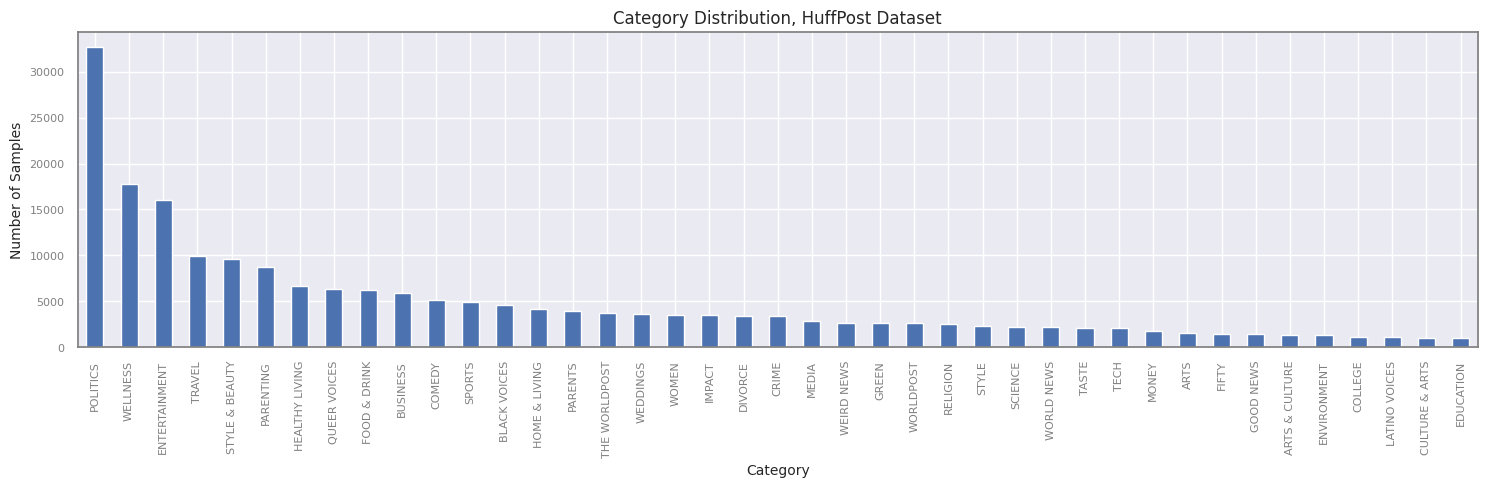

In [ ]:
# Plot class distribution
plt.figure(figsize = (15, 5))
category_counts.plot(kind = 'bar')
plt.title('Category Distribution, HuffPost Dataset', fontsize = 12)
plt.xlabel('Category', fontsize = 10)
plt.ylabel('Number of Samples', fontsize = 10)
plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

In [ ]:
# Word count for headline and short_description
huff_df['headline_word_count']          = huff_df['headline'].apply(lambda x: len(str(x).split()))
huff_df['short_description_word_count'] = huff_df['short_description'].apply(lambda x: len(str(x).split()))

print(f"Average word count | Headlines: {huff_df['headline_word_count'].mean():.2f}, Short Descriptions: {huff_df['short_description_word_count'].mean():.2f}")


Average word count | Headlines: 9.54, Short Descriptions: 19.73


In [ ]:
# Vocabulary size: collate all the text into a bigass list of words, remove the duplicates, then count the number of unique items


all_words       = ' '.join(huff_df['headline'].fillna('') + ' ' + huff_df['short_description'].fillna('')).lower().split()
vocabulary_size = len(set(all_words))
print(f"Total vocabulary size (unique words): {vocabulary_size}")

Total vocabulary size (unique words): 239960


In [ ]:
print("\nDownloading NLTK stopwords...")
try:
    nltk.download('stopwords', quiet=True)
except Exception:
    print("NLTK stopwords could not be downloaded. Please check your network connection.")

In [ ]:
categories_huff = huff_df['category'].unique()
categories_huff

array(['CRIME', 'ENTERTAINMENT', 'WORLD NEWS', 'IMPACT', 'POLITICS',
       'WEIRD NEWS', 'BLACK VOICES', 'WOMEN', 'COMEDY', 'QUEER VOICES',
       'SPORTS', 'BUSINESS', 'TRAVEL', 'MEDIA', 'TECH', 'RELIGION',
       'SCIENCE', 'LATINO VOICES', 'EDUCATION', 'COLLEGE', 'PARENTS',
       'ARTS & CULTURE', 'STYLE', 'GREEN', 'TASTE', 'HEALTHY LIVING',
       'THE WORLDPOST', 'GOOD NEWS', 'WORLDPOST', 'FIFTY', 'ARTS',
       'WELLNESS', 'PARENTING', 'HOME & LIVING', 'STYLE & BEAUTY',
       'DIVORCE', 'WEDDINGS', 'FOOD & DRINK', 'MONEY', 'ENVIRONMENT',
       'CULTURE & ARTS'], dtype=object)

In [ ]:
# --- Define classes and stopwords ---

# "Stopwords" are very common words in a language (like "the", "a", "is", "and") that are often removed during text
# preprocessing in Natural Language Processing (NLP) tasks. They are usually filtered out because they don't carry much meaning
# and can add noise to the data when you're trying to analyze the important terms.



categories_to_analyze = categories_huff
stop_words            = set(stopwords.words('english'))

# Add some additional common, uninformative words that are not in the default list
additional_stopwords = {'said', 'one', 'new', 'get', 'like', 'will', 'us', 'year', 'week', 'day', 'make', 'may', 'go', 'dont', 'didnt', 'can', 'cant'}
stop_words.update(additional_stopwords)

#### Top-N Words by Category

Plotting category: CRIME with 3405 samples
Plotting category: ENTERTAINMENT with 16058 samples
Plotting category: WORLD NEWS with 2177 samples
Plotting category: IMPACT with 3459 samples
Plotting category: POLITICS with 32739 samples
Plotting category: WEIRD NEWS with 2670 samples
Plotting category: BLACK VOICES with 4528 samples
Plotting category: WOMEN with 3490 samples
Plotting category: COMEDY with 5175 samples
Plotting category: QUEER VOICES with 6314 samples
Plotting category: SPORTS with 4884 samples
Plotting category: BUSINESS with 5937 samples
Plotting category: TRAVEL with 9887 samples
Plotting category: MEDIA with 2815 samples
Plotting category: TECH with 2082 samples
Plotting category: RELIGION with 2556 samples
Plotting category: SCIENCE with 2178 samples
Plotting category: LATINO VOICES with 1129 samples
Plotting category: EDUCATION with 1004 samples
Plotting category: COLLEGE with 1144 samples
Plotting category: PARENTS with 3955 samples
Plotting category: ARTS & CULTURE

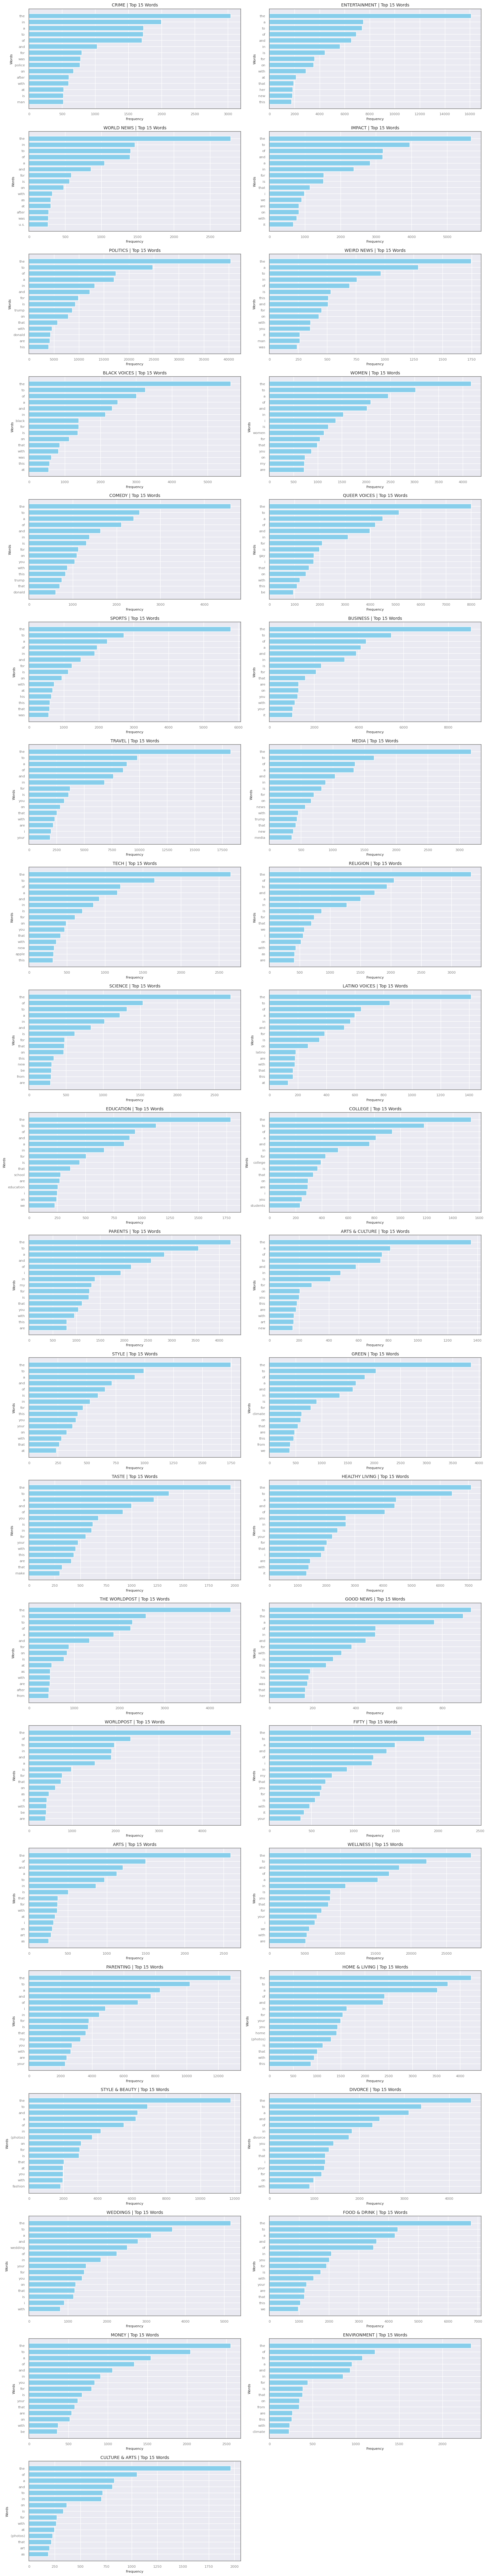

In [ ]:

# Function to get word frequencies
def get_word_frequencies(text_series):
    words = ' '.join(text_series).lower().split()
    return Counter(words)

# grid of subplots
fig, axes = plt.subplots(nrows=21, ncols=2, figsize=(16, 84))
axes = axes.flatten()

for idx, category in enumerate(categories_huff):
    top_n       = 15
    filter      = huff_df['category'] == category
    category_df = huff_df[filter]

    print(f'Plotting category: {category} with {len(category_df)} samples')
    # Combine headlines and short descriptions
    all_text = category_df['headline'].fillna('') + ' ' + category_df['short_description'].fillna('')
    word_counts = get_word_frequencies(all_text)

    # Get top n most common words
    top_words = word_counts.most_common(top_n)
    if not top_words:
        axes[idx].set_visible(False)
        continue

    words, counts = zip(*top_words)

    #   horizontal bar chart
    axes[idx].barh(words, counts, color='skyblue')
    axes[idx].set_xlabel('Frequency', fontsize=8)
    axes[idx].set_ylabel('Words', fontsize=8)
    axes[idx].set_title(f'{category} | Top {top_n} Words', fontsize=10)
    axes[idx].invert_yaxis()

# Hide any unused subplots
for j in range(len(categories_huff), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()


<div class="alert alert-warning">


### Graded Questions (2 pts each)

For each question, answer thoroughly but concisely, in a short paragraph, longer or shorter as needed. Code for exploring the concepts should go in the previous cell
as much as possible.

</div>

#### 1. **Dataset Summary:**  
   Describe your chosen dataset  (as if explaining to your *clueless boss* what you are working on).
   - State which dataset you are going to use.   
   - What kind of data does it contain (i.e. images or text)?  
   - How many samples and classes are there?  
   - What is the task you’ll perform (classification into what categories)?
   - What is the potential business use for this dataset?

##### 1.1. **Your answer here:**

<font color = 'plum'> 

 Chosen Dataset: Huffington Post News Category

|  |  |
| :--- | :--- |
| **Total Number of Samples** | 200,853 |
| **Number of Features** | 6 |
| **Classification Task Type** | Multi-class Classification |
| **Number of Distinct Classes / Categories** | 41 |

<font color = 'plum'>**Features and Data Types**

* **`category`**:  target label (text/string, representing one of the 41 news categories).
* **`headline`**:  title of news article (text/string).
* **`short_description`**:  brief summary of  article (text/string).
* **`date`**:  publication date (date/string).
* **`authors`**:  author(s) of article (text/string).
* **`link`**:  URL to  original article (text/string).

- Primary input data type: **text**

 <font color = 'plum'>**Classification Task**
- **Task**:  Natural Language Processing (NLP) **multi-class classification**.

- **Goal**: predict  `category` given  article text (likely a combination of `headline` and `short_description`).

  - The model must correctly assign a given news article to one of the **41 distinct news categories** (e.g., *Politics*, *Sports*, *Travel*, *Science*).
  - 41 classes --> model complexity will be higher than a binary classification task; class imbalance will need to be managed.


#### 2. **Initial Observations:**  
   What stood out to you from your EDA?  
   - Did you notice any imbalanced or ambiguous classes?  
   - Any patterns, anomalies, or potential sources of bias?  
   - For images: note any variation in lighting, composition, or color.  
   - For text: mention redundancy, topic overlap, or very short examples.

##### 1.2. **Your answer here:**

<font color = 'plum'>


**Class balance & ambiguity**
- Noticeable imbalance—big buckets like POLITICS and ENTERTAINMENT dominate, while tails (e.g., GOOD NEWS, QUEER VOICES, COLLEGE) are small.
- Several overlapping/ambiguous labels (TECH vs SCIENCE, WORLD NEWS vs POLITICS, STYLE vs STYLE & BEAUTY, PARENTS vs PARENTING) can confuse classifiers.

**Text patterns**
- short headlines (often ≤ 12 words)
-  descriptions vary widely and include near-duplicates/reposts and redundant phrasing phrasing.
-  Lots of named entities (people, orgs, places); spikes in repeated terms around major events (topic drift).

**Potential bias**
- Strong US-centric/editorial slant (the data is from Huffington Post USA)
- temporal skew (e.g., politics surge in certain years)
- Underrepresented categories risk minority-class underperformance.

**Data quality quirks**
- Occasional missing/blank authors, repeated URLs, and mismatched section labels
- headlines/descriptions can be so terse as to come across as duplicates when in fact unique are extremely.

**Modeling implications**
- Expect class-imbalance handling (class weights/focal loss), label consolidation or hierarchical labels to reduce overlap, deduplication/near-duplicate filtering, and time-aware splits to mitigate topic drift.




#### 3. **Challenges & Implications:**  
   Based on your inspection, what challenges might affect model performance or training (e.g., imbalance, ambiguous labels, variable quality)?  

#####   1.3. **Your answer here:** 

<font color = 'plum'>

**Class imbalance:**  
- A few categories (like *POLITICS* and *ENTERTAINMENT*) dominate the dataset, while others (e.g., *GOOD NEWS*, *QUEER VOICES*) have very few samples.  
  This can cause the model to favor majority classes and misclassify minority ones.

**Ambiguous or overlapping labels**
- Some categories are semantically close (*TECH* vs. *SCIENCE*, *STYLE* vs. *STYLE & BEAUTY*), which may confuse the model during training.

**Variable text quality:**  
- Headlines are often extremely short, and descriptions vary widely in length and tone.  
- Some contain repetitive phrasing or minimal context, limiting the information available for classification.

**Redundancy and duplication:**  
- Multiple entries share nearly identical headlines or content, which can lead to overfitting.

**Bias:**  
- The dataset reflects editorial and cultural biases of *HuffPost*, such as a U.S.-centric perspective and event-driven topic spikes.  
- may limit generalization to other news sources or international content.


**Overall:**  
We'll need to carefully implement **data balancing**, **label cleaning**, and **regularization or augmentation** to build a more generalizable model.

#### 4. **Preparation Ideas:**  
   What data-cleaning or preprocessing steps might help address these issues?  
   (You will not implement these yet—just describe what you might do later.)

#####  1.4. **Your answer here**

<font color = 'plum'>

**1. Duplicates & Leakage**
- **Action:** Remove exact and near-duplicate entries using hashing (e.g., MinHash/SimHash).  
- **Why:** Prevents data leakage where the same article appears in both training and test sets, inflating performance metrics.


**2. Class Imbalance**
- **Action:** Use **stratified splits**, apply **class weights** or **focal loss**, and consider **data augmentation** (e.g., back-translation or paraphrasing).  
- **Why:** Balances underrepresented categories and improves recall for minority classes.

**3. Ambiguous / Overlapping Labels**
- **Action:** Merge or normalize semantically similar labels (*e.g.,* `STYLE` and `STYLE & BEAUTY`), or use a **hierarchical classification** scheme.  
- **Why:** Reduces confusion among similar categories

**4. Variable Text Quality & Short Examples**
- **Action:** Concatenate `headline + short_description`, filter out entries with < 3 tokens, and cap long examples at 512 tokens.  
- **Why:** Ensures sufficient textual context while maintaining consistent input length for models.

**5. Redundancy & Event Bursts**
- **Action:** Use **time-aware splits** (train on older data, validate/test on newer) and down-weight repetitive headlines.  
- **Why:** To simulate real-world deployment conditions and avoid overfitting to trending topics.


**6. Bias & Domain Skews**
- **Action:** Evaluate performance across subgroups (e.g., by time, category), and consider reweighting data distributions or domain adaptation.  
- **Why:** for fairness and robustness across time periods and content types.


**7. Tokenization & Vocabulary**
- **Action:** Use **subword tokenizers** (BPE, WordPiece), prune rare tokens, and cap the vocabulary size (e.g., 30k–70k).  
- **Why:** Prevents sparsity and improves generalization to unseen text.

**8. Feature Enrichment**
- **Action:** Add *entity-based* tokens (e.g., names, locations), include section keywords, or highlight headline tokens.  
- **Why:** Strengthens semantic representation and improves topical classification.


#### 5. **Reflection:**  
   Why did you choose this dataset over the other one?  
   - What makes it more interesting, realistic, or relevant for you?  
   - What do you expect to learn from working with it?

##### 1.5. **Your answer here:**

<font color = 'plum'> 

We chose the HuffPost News Category Dataset because it’s realistic, diverse, and relevant to real-world NLP applications like multi-class text classification challenges. And it's practical industry data with natural imbalance, so it's a great exercise in handling noisy unbalanced text data.
</font>

## Problem 2 – Frame the Problem (15 pts)



#### Objective

Identify the **key challenges** in your chosen dataset and outline **practical solutions** you would try, plus how you’ll **evaluate** them later.

#### Steps to follow

1. **Diagnose likely challenges (from your EDA):**

   Examples:
   * **Class imbalance:**
     Report label counts and an imbalance ratio (max / median). List any minority classes.
   * **Length/size variance:**
     For text, show length percentiles (50/75/90/95) and estimate truncation rate at candidate `max_text_length`s (e.g., 256/300/512). For images, summarize native resolutions.
   * **Noise/duplicates/leakage:**
     Note empty or malformed items, near-duplicates, and how you would prevent cross-split leakage.
   * **Ambiguous/overlapping labels:**
     Give 2–3 example pairs you expect to be confusable and why.
   * **Compute constraints:**
     Briefly state limits (RAM/GPU/CPU) that might affect batch size, sequence length, or image size.

2. **Map each challenge to a concrete solution plan:**

   Examples:
   * **Imbalance →** `class_weight` or oversampling; report which one you’d try first and why.
   * **Length/size →** pick a target `max_text_length` (e.g., 95th percentile) with masking; for images, standardize resize/crop and basic augmentation.
   * **Noise/duplicates →** dedupe (hash/near-dup), drop empty/very short items, document any relabeling.
   * **Ambiguity →** consider merging labels (if justified), or add features (bigrams/char-ngrams; simple image augmentations).
   * **Overfitting risk →** early stopping on your primary metric, dropout/weight decay, freeze-then-finetune plan (for pretrained features).

3. **Explore appropriate evaluation metrics:**

   Examples:
   * **Primary metric:** pick one aligned to your data (e.g., **macro-F1** if imbalanced; accuracy if balanced).
   * **Secondary metric(s):** per-class precision/recall, confusion matrix.
   * **Protocol:** stratified Train/Val/Test (e.g., 70/15/15), fixed seed, leakage checks.

4. **Answer the graded questions below.**



In [ ]:
# Your code here, add as many cells as you like. Provide organization and structure by appropriate comments, labels, and variable names. Explain what
# you are doing in case you come back to this in a year.



In [ ]:
from collections import Counter

df = huff_df

# --- Class Imbalance ---
label_counts    = df['category'].value_counts()
max_count       = label_counts.max()
median_count    = label_counts.median()
imbalance_ratio = round(max_count / median_count, 2)

print("\n--- Class Imbalance ---")
print(f"Max label count: {max_count}")
print(f"Median label count: {median_count}")
print(f"Imbalance ratio (max/median): {imbalance_ratio}")
print("\nTop 10 classes:\n", label_counts.head(10))
print("\nBottom 10 classes:\n", label_counts.tail(10))

# --- Text Length Stats ---
df['text']      = (df['headline'].fillna('') + " " + df['short_description'].fillna('')).str.strip()
df['length']    = df['text'].apply(lambda x: len(x.split()))

percentiles = np.percentile(df['length'], [50, 75, 90, 95])
print("\n--- Text Length (in tokens) ---")
print(f"50th percentile: {percentiles[0]:.1f}")
print(f"75th percentile: {percentiles[1]:.1f}")
print(f"90th percentile: {percentiles[2]:.1f}")
print(f"95th percentile: {percentiles[3]:.1f}")

# Truncation rates
for max_len in [256, 300, 512]:
    trunc_rate = (df['length'] > max_len).mean() * 100
    print(f"Truncation rate @ max_len={max_len}: {trunc_rate:.2f}%")

# --- Duplicates & Empty Texts ---
dup_count   = df.duplicated(subset=['text']).sum()
empty_count = (df['text'].str.strip() == '').sum()

print("\n--- Noise & Duplicates ---")
print(f"Duplicate entries: {dup_count}")
print(f"Empty/malformed entries: {empty_count}")

# --- Ambiguous Label Pairs (expected confusions) ---
confusable_pairs = [
    ("TECH", "SCIENCE"),
    ("WORLD NEWS", "POLITICS"),
    ("STYLE", "STYLE & BEAUTY")
]
print("\n--- Likely Ambiguous/Overlapping Labels ---")
for a, b in confusable_pairs:
    print(f" - {a} ↔ {b}")


--- Class Imbalance ---
Max label count: 32739
Median label count: 3405.0
Imbalance ratio (max/median): 9.61

Top 10 classes:
 category
POLITICS          32739
WELLNESS          17827
ENTERTAINMENT     16058
TRAVEL             9887
STYLE & BEAUTY     9649
PARENTING          8677
HEALTHY LIVING     6694
QUEER VOICES       6314
FOOD & DRINK       6226
BUSINESS           5937
Name: count, dtype: int64

Bottom 10 classes:
 category
MONEY             1707
ARTS              1509
FIFTY             1401
GOOD NEWS         1398
ARTS & CULTURE    1339
ENVIRONMENT       1323
COLLEGE           1144
LATINO VOICES     1129
CULTURE & ARTS    1030
EDUCATION         1004
Name: count, dtype: int64

--- Text Length (in tokens) ---
50th percentile: 28.0
75th percentile: 35.0
90th percentile: 49.0
95th percentile: 56.0
Truncation rate @ max_len=256: 0.00%
Truncation rate @ max_len=300: 0.00%
Truncation rate @ max_len=512: 0.00%

--- Noise & Duplicates ---
Duplicate entries: 488
Empty/malformed entries: 5



In [ ]:
# 1) Normalize
df = huff_df.dropna(subset=["headline", "short_description"])
df["text"] = (df["headline"].str.strip() + " [SEP] " +
              df["short_description"].fillna("").str.strip())
df["text"] = (df["text"]
              .str.normalize("NFKC")
              .str.replace(r"\s+", " ", regex=True)
              .str.lower())

# 2) Dedup (exact + near-dup optional)
df = df.drop_duplicates(subset=["text"])
# near-dup: use datasketch MinHash LSH on token shingles (omitted here)

# 3) Length filter
tok = df["text"].str.split()
df  = df[(tok.str.len() >= 3) & (tok.str.len() <= 512)]

# 4) Stratified split by category
from sklearn.model_selection import StratifiedShuffleSplit
sss                 = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(sss.split(df["text"], df["category"]))
train, test         = df.iloc[train_idx], df.iloc[test_idx]

# 5) Class weights (for sklearn/pyTorch)
from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(train["category"])
weights = compute_class_weight("balanced", classes=classes,
                               y=train["category"])
class_weight = dict(zip(classes, weights))
display(class_weight)

{'ARTS': np.float64(3.2381837654333463),
 'ARTS & CULTURE': np.float64(3.652792341007522),
 'BLACK VOICES': np.float64(1.080289608866238),
 'BUSINESS': np.float64(0.8237065974453212),
 'COLLEGE': np.float64(4.276244863105086),
 'COMEDY': np.float64(0.9488924022525003),
 'CRIME': np.float64(1.4364159518111168),
 'CULTURE & ARTS': np.float64(4.749073881990339),
 'DIVORCE': np.float64(1.4274973721249264),
 'EDUCATION': np.float64(4.8673571667223525),
 'ENTERTAINMENT': np.float64(0.3043756564814305),
 'ENVIRONMENT': np.float64(3.694222877956568),
 'FIFTY': np.float64(3.499093827106579),
 'FOOD & DRINK': np.float64(0.78483690861005),
 'GOOD NEWS': np.float64(3.4959640472970026),
 'GREEN': np.float64(1.8674093668791443),
 'HEALTHY LIVING': np.float64(0.7311050888286661),
 'HOME & LIVING': np.float64(1.1740726358900717),
 'IMPACT': np.float64(1.4135579764477573),
 'LATINO VOICES': np.float64(4.328336439510575),
 'MEDIA': np.float64(1.7371056910569105),
 'MONEY': np.float64(2.863361029214688),

<div class="alert alert-warning">

### Graded Questions (3 pts each)

For each question, answer thoroughly but concisely, in a short paragraph, longer or shorter as needed. Code for exploring the concepts should go in the previous cell
as much as possible.

</div>

#### 1. **State the prediction task**  
   - Describe what your model will predict (the *label*).  
   - *Examples:*  
     - “Given a photo of food, predict which of 101 categories it belongs to.”  
     - “Given a news headline + summary, predict its topical category.”  

#####  2.1. **Your answer here:**

<font color = 'plum'>

We're performing <font color = 'cyan'>single-label multiclass text classification</font>. <br>

Given an article’s headline (and optionally its short_description), predict which of the dataset’s 41 classes (or 'categories', e.g. POLITICS, ENTERTAINMENT, SPORTS, WORLD NEWS, SCIENCE, TECH, etc.).

In detail, the model will output a probability distribution over all categories (likely via `softmax`), and the predicted label will be the category with the highest probability. Optionally, we can expose top-k probabilities for downstream use (e.g., routing or human review).

#### 2. **Define inputs and outputs**  
   - *Inputs:* what information the model receives (e.g., pixel data, tokenized text).  
   - *Outputs:* the categorical label the model will predict.  

#####  2.2. **Your answer here:**

<font color = 'plum'>

**Inputs**  
- model receives the `headline` and `short_description` text fields from each news article.  
- prior to model ingestion, the text is **tokenized** (converted into numerical sequences or embeddings) using methods such as **Word2Vec**, **GloVe**, or **transformer-based tokenizers** (e.g., BERT).  
- Additional preprocessing steps include **lowercasing**, **duplicate removal**, and **truncation** to a maximum sequence length (e.g., 256 tokens).

**Outputs**  
- a **categorical label** representing the predicted **news category** (one of 41 possible classes).  
- output is typically represented as a probability distribution across all categories, with the **highest-probability label** selected as the model’s final prediction.


#### 3. **Identify possible challenges**  
   - Imbalanced classes, noisy data, ambiguous labels, overlapping features, or missing data  
   - *Images:* variation in lighting, color, composition, or size.  
   - *Text:* class imbalance, duplicate stories, short or ambiguous headlines.  

##### 2.3. **Your answer here:**

<font color = 'plum'> 

For the **HuffPost News Category Dataset**, several challenges may impact model performance:

- **Class Imbalance:**  
  A few categories such as *POLITICS* and *ENTERTAINMENT* dominate the dataset, while others like *GOOD NEWS* or *QUEER VOICES* have very few samples.  
  This imbalance can cause the model to favor frequent categories and misclassify minority ones.

- **Noisy or Duplicate Data:**  
  The dataset includes duplicate headlines, reposted stories, and near-identical descriptions across multiple entries.  
  These redundancies can lead to overfitting and inflated performance metrics if not removed before splitting.

- **Ambiguous or Overlapping Labels:**  
  Some categories are semantically similar, such as *TECH* vs. *SCIENCE* or *STYLE* vs. *STYLE & BEAUTY*, which can confuse the model and reduce classification precision.

- **Short or Vague Text Inputs:**  
  Many headlines are extremely short or lack sufficient context, making it difficult for the model to learn meaningful distinctions between classes.

- **Potential Bias:**  
  As the data comes from a single news outlet (*HuffPost*), it reflects editorial and cultural biases—primarily U.S., centric topics, which could limit generalization to other sources.

Together, these challenges require **careful preprocessing**, **data balancing**, and **robust evaluation** to ensure fair and reliable model performance.


#### 4. **Propose how you will prepare or improve the data to address the challenges**  
   - *Images:* resizing, normalization, data augmentation (flips, rotations, brightness, color jitter).  
   - *Text:* tokenization, stop-word removal, TF-IDF, class balancing, embeddings (choose an embedding approach and specify its vector size).

##### <font color = 'plum'> 2.4. **Your answer here:**
1) **Global hygiene**
- **Deduplicate**: Drop exact and near-duplicate `headline + short_description` (e.g., text hash + MinHash).
- **Leakage prevention**: Deduplicate **before** splitting; group by `link` so the same story can’t land in both train and test.
- **Time-aware split**: Train on older, validate/test on newer to reduce event-burst bias.
- **Normalize text**: Unicode NFKC, lowercase, collapse whitespace; remove empty/≤2-token samples.

---

2) **Class imbalance mitigation**
- **Stratified split** by `category`.
- **Training**: class **weights** (or **focal loss**) to lift minority classes.
- **Data augmentation** (for tails): light **back-translation**, synonym swaps, or template paraphrases; cap per-class oversampling to avoid drift.

---

3) **Ambiguous/overlapping labels**
- **Label normalization**: Merge or map near-duplicates (e.g., `STYLE` ↔ `STYLE & BEAUTY`) if project allows.
- **Hierarchical targets**: Train/evaluate at top-level topics first; optionally fine-tune to sublabels.
- **Calibration & thresholds**: Apply Platt/isotonic calibration; allow **top-k** predictions for borderline cases.

---

4) **Length/size variance**
- **Concatenate** headline + description with a separator.
- **Cap length** at **256**; optionally run sensitivity at 320/384.
- **Short texts**: keep (they’re common in news); rely on model/context features rather than aggressive filtering.



#### 5. **Specify success metrics**  
   - Identify the metrics you plan to use to evaluate model performance—typically **accuracy** and/or **F1-score**, which are standard for classification tasks.  

   - Briefly explain **why** these metrics are appropriate for your dataset and goal. For instance, accuracy may suffice for well-balanced datasets, while F1-score better reflects performance when some classes are under-represented.

   - If your dataset is **imbalanced**, consider computing **per-class metrics** (e.g., precision, recall, or F1 for each label) or **macro-averaged** scores, which give equal weight to each class regardless of its size—ensuring that minority classes are evaluated fairly.
   
In some cases, weighted averages (which weight classes by their frequency) or **confusion matrices** can also provide useful insight.
> You haven't run any models yet, and we haven’t studied every possible metric, but you’re encouraged to ask your favorite generative AI tool which evaluation metrics might best fit your dataset!
   - Clearly state how you will interpret success—for example, “Our goal is to achieve at least 80% overall accuracy without large per-class disparities.”

#####  2.5. **Your answer here:**

<font color = 'plum'>

**Primary Metric**  
- **Macro F1-score** (averaged across all 41 classes)  
  *Reason:* Since the dataset is imbalanced, accuracy alone could be misleading. The Macro F1-score gives **equal weight** to all classes, ensuring fair evaluation of both frequent and rare categories.

---

**Secondary Metrics**  
- **Overall Accuracy:** Provides an easy-to-understand performance summary, though less informative for imbalanced data.  
- **Weighted F1-score:** Weights class F1 scores by their frequency, reflecting performance on the real-world class distribution.  
- **Per-class Precision/Recall/F1:** Identifies underperforming or ambiguous classes.  
- **Confusion Matrix:** Highlights systematic misclassifications (e.g., *TECH* vs. *SCIENCE*).  
- **Macro PR-AUC (optional):** Evaluates ranking quality, especially helpful for imbalanced datasets.  
- **Calibration Metrics:** Such as Expected Calibration Error (ECE) or Brier Score, useful if probabilistic outputs are deployed.

---

**Fairness & Robustness Checks**  
- Compute **slice metrics** by head vs. tail classes and over time (older vs. newer samples) to detect distribution drift.  
- Monitor **validation–test gaps** to assess generalization consistency.

---

**Success Criteria**

- **Macro F1 ≥ 0.80** on the test set  
- **Overall Accuracy ≥ 0.88**  
- **Per-class F1 ≥ 0.60** for at least **90%** of categories  
- **No class with F1 < 0.40**  
- **Top-3 Recall ≥ 0.95** (for multi-choice scenarios)  
- **Validation–Test Macro F1 gap ≤ 0.02**  
- **ECE ≤ 0.05** (if probabilities are used)

---

**Interpretation:**  
The model will be considered successful if it achieves **Macro F1 ≥ 0.80** with balanced per-class performance and minimal overfitting, indicating strong generalization and fairness across all categories.

## Final Question: Describe what use you made of generative AI tools in preparing this Milestone.

###  **AI Question: Your answer here:**

<font color = 'plum'> 

As of this writing, our primary use of generative AI has focused on 1) considerations in data preparation, and 2) establishing and understanding criteria and thresholds for successful model performance. 

---

## Appendix: A quick guide to Hugging Face Datasets



#### 1) What are they?

* A **table-like** dataset: rows = examples, columns = named fields (e.g., `"image"`, `"label"`, `"headline"`).
* Backed by **Apache Arrow** → fast, memory-efficient, lazy transforms.
* Two core objects:

  * `Dataset` — one table of rows/columns.
  * `DatasetDict` — a dict of splits, e.g. `{"train": Dataset, "val": Dataset, "test": Dataset}`.




#### 2) Load and inspect

```python
from datasets import load_dataset

# Food-101 (images)
food = load_dataset("food101", split="train+validation")  # both splits at once
len(food), food.column_names, food.features
# -> (≈101000, ['image','label'], {'label': ClassLabel(num_classes=101, names=[...])})

# Access by name (not by numeric column index!)
row0 = food[0]
img0, y0 = row0["image"], row0["label"]     # PIL image, int id
label_names = food.features["label"].names
label_names[y0]
```

For text (HuffPost JSON mirror):

```python
url = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"
huff = load_dataset("json", data_files=url, split="train")
huff.column_names  # e.g. ['headline','short_description','category','authors','link','date']
```


#### 3) Common transforms

`Dataset`s are **immutable**: ops return a new dataset.

* **Map** (add/modify columns):

```python
def mk_text(ex):
    h = (ex.get("headline") or "").strip()
    s = (ex.get("short_description") or "").strip()
    return {"text": (h + " [SEP] " + s).strip()}

huff = huff.map(mk_text)  # adds 'text' column
```

* **Class-encode** labels (strings → integers with a vocabulary):

```python
from datasets.features import ClassLabel
if not isinstance(huff.features["category"], ClassLabel):
    huff = huff.class_encode_column("category")  # now ints with .names
```

* **Filter / select / rename / drop**:

```python
small = huff.select(range(5000))  # first 5k rows
huff = huff.remove_columns(["authors","link","date"])
huff = huff.rename_column("category", "label")
```

#### 4) Splitting & shuffling

```python
# Stratified 80/10/10 on Food-101 by 'label'
from datasets import DatasetDict
label_col = "label"

tmp = food.train_test_split(test_size=0.10, seed=42, stratify_by_column=label_col)
train_val = tmp["train"].train_test_split(test_size=1/9, seed=42, stratify_by_column=label_col)
ds = DatasetDict(train=train_val["train"], val=train_val["test"], test=tmp["test"])

len(ds["train"]), len(ds["val"]), len(ds["test"])
```

* `train_test_split` is **random by default** (reproducible with `seed=`).
* You typically **don’t need to pre-shuffle** datasets if your training dataloader already shuffles each epoch.


#### 5) Working with images

Use `with_transform` to apply on-the-fly resizing/augmentation and return tensors:

```python
import torchvision.transforms as T
from torch.utils.data import DataLoader
import torch, math, random

IM_SIZE = 224
train_tfms = T.Compose([T.RandomResizedCrop(IM_SIZE), T.RandomHorizontalFlip(), T.ToTensor()])
eval_tfms  = T.Compose([T.Resize(256), T.CenterCrop(IM_SIZE), T.ToTensor()])

def add_pixel_values(ex, tfms):  # ex['image'] -> ex['pixel_values']
    ex = dict(ex); ex["pixel_values"] = tfms(ex["image"]); return ex

train_t = ds["train"].with_transform(lambda ex: add_pixel_values(ex, train_tfms))
val_t   = ds["val"].with_transform(lambda ex: add_pixel_values(ex, eval_tfms))

def collate(batch):
    return {"pixel_values": torch.stack([b["pixel_values"] for b in batch]),
            "labels": torch.tensor([b["label"] for b in batch])}

train_loader = DataLoader(train_t, batch_size=64, shuffle=True,  collate_fn=collate)
val_loader   = DataLoader(val_t,   batch_size=64, shuffle=False, collate_fn=collate)
```

### 6) Working with Text

You can preprocess and tokenize text datasets using either a **transformer tokenizer** or a **linguistic pipeline like spaCy**, depending on your model type and goals.


#### Option A: Transformer Tokenizer (for fine-tuning models like BERT or DistilBERT)

Use a pretrained tokenizer with the Hugging Face `map` method to efficiently process your dataset in batches:

```python
from transformers import AutoTokenizer

tok = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tok(batch["text"], truncation=True, padding="max_length", max_length=128)

tokenized = huff.map(
    tokenize,
    batched=True,
    remove_columns=[c for c in huff.column_names if c not in ("category", "label")]
)
```

This produces token IDs, attention masks, and other fields expected by transformer models.
Use this approach if your project involves fine-tuning pretrained language models.


#### Option B: spaCy Tokenization and Cleaning (for classical ML or custom preprocessing)

If you are **not using transformers**, or if you want to explore feature engineering (e.g., TF-IDF, word frequency, or embedding averages), you can preprocess text with **spaCy** instead.

```python
# !pip install spacy
# !python -m spacy download en_core_web_sm

import spacy
from datasets import load_dataset

nlp = spacy.load("en_core_web_sm", disable=["ner", "parser", "textcat"])
STOP = spacy.lang.en.stop_words.STOP_WORDS

def spacy_clean(batch):
    docs = list(nlp.pipe(batch["text"], batch_size=1000))
    cleaned = []
    for doc in docs:
        tokens = [t.lemma_.lower() for t in doc if t.is_alpha and not t.is_stop]
        cleaned.append(" ".join(tokens))
    return {"text_clean": cleaned, "len_tokens": [len(c.split()) for c in cleaned]}

huff = huff.map(
    spacy_clean,
    batched=True,
    batch_size=1000,
    remove_columns=[c for c in huff.column_names if c not in ("category", "label")]
)
```

The resulting column `text_clean` can be used with:

* `TfidfVectorizer` (Scikit-learn)
* `TextVectorization` (Keras)
* or any other custom embedding method.

> 💡 **Tip:** spaCy is ideal for lightweight NLP pipelines or for models that rely on explicit preprocessing (lemmatization, stopword removal). Transformer tokenizers, by contrast, expect *raw text* and handle subword tokenization internally.



#### 7) Slicing, concatenating, saving

```python
# Slicing
head_1000 = food.select(range(1000))
tail_10pct = food.select(range(int(0.9*len(food)), len(food)))

# Concatenate splits/datasets
from datasets import concatenate_datasets
all_train = concatenate_datasets([ds["train"], ds["val"]])

# Save / reload
ds.save_to_disk("food101_splits")
from datasets import load_from_disk
ds2 = load_from_disk("food101_splits")
```


#### 8) Quick “gotchas”

* **Columns by name** (strings), not numeric indices.
* Avoid converting huge columns to `list(...)` unless necessary; prefer vectorized ops with `map`, `filter`, `select`.
* `PYTHONHASHSEED` must be set **before** the Python process starts to matter; use explicit `seed=` arguments for reproducibility.
* Datasets print **previews** (e.g., `Column([6, 6, 6, ...])` is just the first few values).


#### 9) A minimal checklist to follow

1. `load_dataset(...)` → confirm `column_names`, `features`.
2. Build any needed columns (`"text"`), and **class-encode** labels if strings.
3. Make a **stratified 80/10/10** split (`train_test_split` ×2).
4. Do **EDA**: class counts, sample printouts or image grids.
5. For training:

   * **images** → `with_transform` + DataLoader
   * **text** → tokenizer via `.map(...)` + trainer/model pipeline
6. Save your `DatasetDict` with `save_to_disk(...)` (optional for text but handy, **don't** use it for big image datasets).

